1. Çeyreklik (Q1): 4300000.0
3. Çeyreklik (Q3): 11499250.0
Çeyreklikler Açıklığı (IQR): 7199250.0
Alt Sınır: 4300000.0
Üst Sınır: 11499250.0


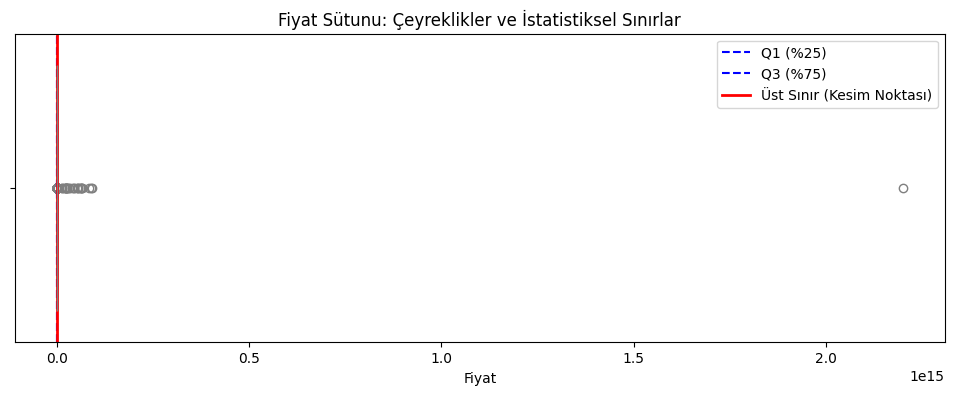

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = '../scraping/data/train_data.csv'
df = pd.read_csv(file_path)

fiyat_verisi = df['fiyat'].dropna()

Q1 = fiyat_verisi.quantile(0.25)
Q3 = fiyat_verisi.quantile(0.75)
IQR = Q3 - Q1

alt_sinir = Q1 
ust_sinir = Q3

print(f"1. Çeyreklik (Q1): {Q1}")
print(f"3. Çeyreklik (Q3): {Q3}")
print(f"Çeyreklikler Açıklığı (IQR): {IQR}")
print(f"Alt Sınır: {alt_sinir}")
print(f"Üst Sınır: {ust_sinir}")

# Çeyreklikleri Boxplot Üzerinde Görselleştirme
plt.figure(figsize=(12, 4))
sns.boxplot(x=fiyat_verisi, color='lightgray')

# Sınır çizgilerini grafiğe ekleyelim
plt.axvline(x=Q1, color='blue', linestyle='--', label='Q1 (%25)')
plt.axvline(x=Q3, color='blue', linestyle='--', label='Q3 (%75)')
plt.axvline(x=ust_sinir, color='red', linestyle='-', linewidth=2, label='Üst Sınır (Kesim Noktası)')

plt.title('Fiyat Sütunu: Çeyreklikler ve İstatistiksel Sınırlar')
plt.xlabel('Fiyat')
plt.legend()
plt.show()

In [ ]:
gercek_alt_sinir = max(0, alt_sinir)

temiz_df = df[(df['fiyat'] >= gercek_alt_sinir) & (df['fiyat'] <= ust_sinir)].copy()

silinen_kayit_sayisi = len(df) - len(temiz_df)
yuzde_silinen = (silinen_kayit_sayisi / len(df)) * 100

print(f"Toplam Orijinal Veri Sayısı: {len(df)}")
print(f"Temizlenmiş Veri Sayısı: {len(temiz_df)}")
print(f"Silinen Aykırı Değer Sayısı: {silinen_kayit_sayisi}")
print(f"Veri Setinin Yüzde Kaçı Silindi: %{yuzde_silinen:.2f}")

Toplam Orijinal Veri Sayısı: 27462
Temizlenmiş Veri Sayısı: 13782
Silinen Aykırı Değer Sayısı: 13680
Veri Setinin Yüzde Kaçı Silindi: %49.81


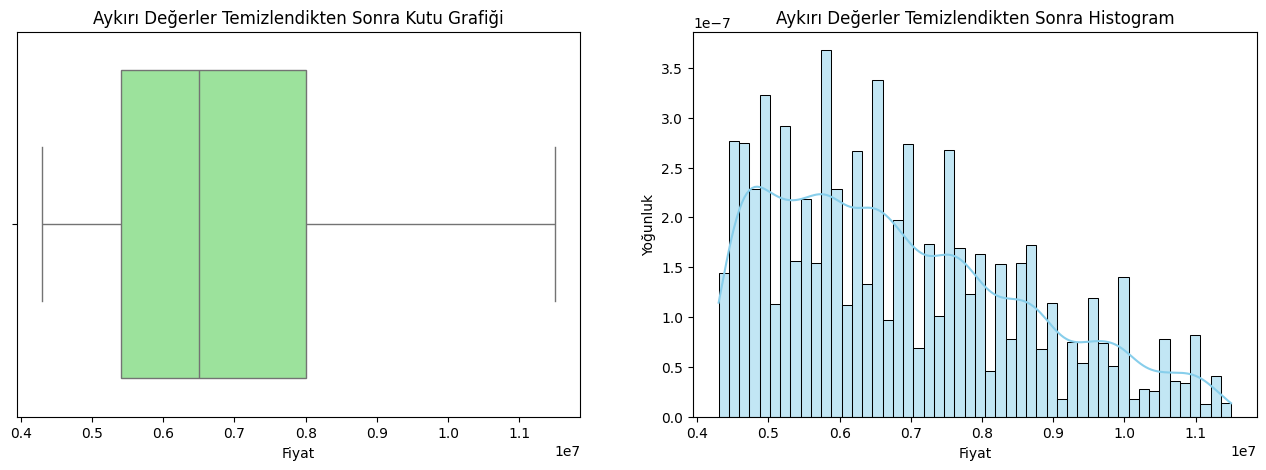

In [51]:
temiz_fiyat = temiz_df['fiyat'].dropna()

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Yeni Kutu Grafiği
sns.boxplot(x=temiz_fiyat, color='lightgreen', ax=ax[0])
ax[0].set_title('Aykırı Değerler Temizlendikten Sonra Kutu Grafiği')
ax[0].set_xlabel('Fiyat')

# Yeni Histogram
sns.histplot(temiz_fiyat, kde=True, stat="density", color='skyblue', bins=50, ax=ax[1])
ax[1].set_title('Aykırı Değerler Temizlendikten Sonra Histogram')
ax[1].set_xlabel('Fiyat')
ax[1].set_ylabel('Yoğunluk')

plt.show()